# Car Price Prediction: Linear, Ridge and Lasso Regression

## Problem Statement

Build a Linear Regression model to predict car price. Apply Ridge and Lasso regularization, compare their coefficients, evaluate all three models using MAE, MSE, RMSE and R², and identify which model generalizes best.

**Target variable:** `price`

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

- `pandas` loads and works with table data.
- `numpy` performs numerical operations.
- `matplotlib` and `seaborn` create graphs.
- `warnings.filterwarnings('ignore')` hides unnecessary warnings.

## 2. Load the Dataset

In [2]:
# This works locally and on Kaggle
import os

possible_paths = [
    'CarPrice_Assignment.csv',
    '/kaggle/input/car-price-prediction/CarPrice_Assignment.csv'
]

file_path = next((path for path in possible_paths if os.path.exists(path)), None)

if file_path is None:
    raise FileNotFoundError('Add CarPrice_Assignment.csv to the notebook.')

df = pd.read_csv(file_path)
print('Dataset loaded from:', file_path)

Dataset loaded from: CarPrice_Assignment.csv


- `possible_paths` contains the common local and Kaggle file locations.
- `os.path.exists()` checks which path is available.
- `pd.read_csv()` loads the CSV into a DataFrame called `df`.

## 3. Basic Checks

In [3]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
print('Rows and columns:', df.shape)
df.info()

Rows and columns: (205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize      

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


In [6]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


These checks show sample rows, dataset size, column types, summary statistics, missing values and duplicate rows.

## 4. Data Cleaning

In [7]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Extract company name from CarName before removing the full model name
df['CompanyName'] = df['CarName'].str.split().str[0].str.lower()

# Correct spelling variations in company names
company_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}
df['CompanyName'] = df['CompanyName'].replace(company_corrections)

# car_ID is only an identifier; CarName is replaced by CompanyName
df = df.drop(columns=['car_ID', 'CarName'])

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (205, 25)


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CompanyName
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


- `drop_duplicates()` removes repeated rows.
- `str.split().str[0]` extracts the manufacturer from the full car name.
- `replace()` corrects inconsistent company spellings.
- Identifier and full model-name columns are removed because they do not provide a reusable numeric pattern.

## 5. Exploratory Data Analysis

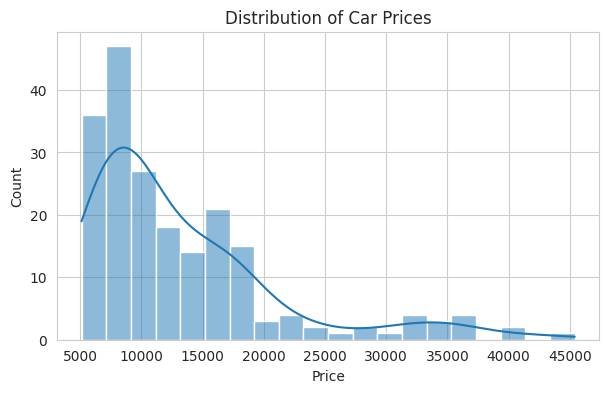

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.show()

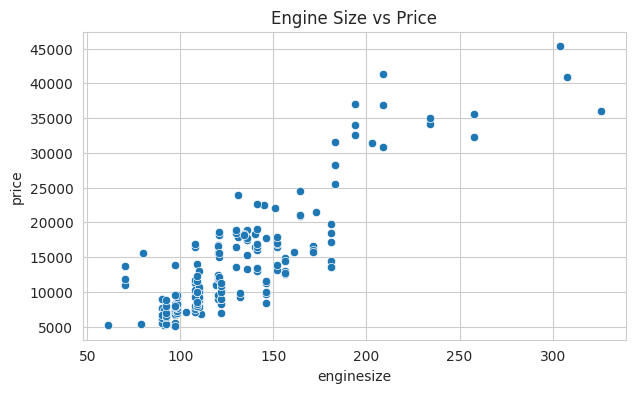

In [9]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='enginesize', y='price')
plt.title('Engine Size vs Price')
plt.show()

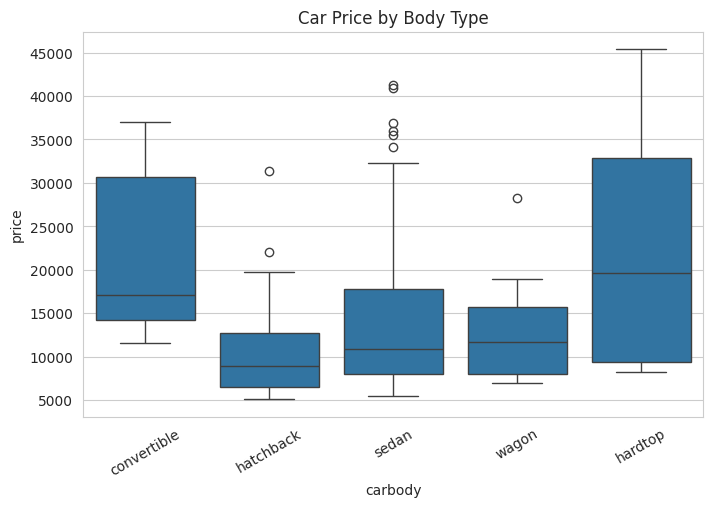

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='carbody', y='price')
plt.title('Car Price by Body Type')
plt.xticks(rotation=30)
plt.show()

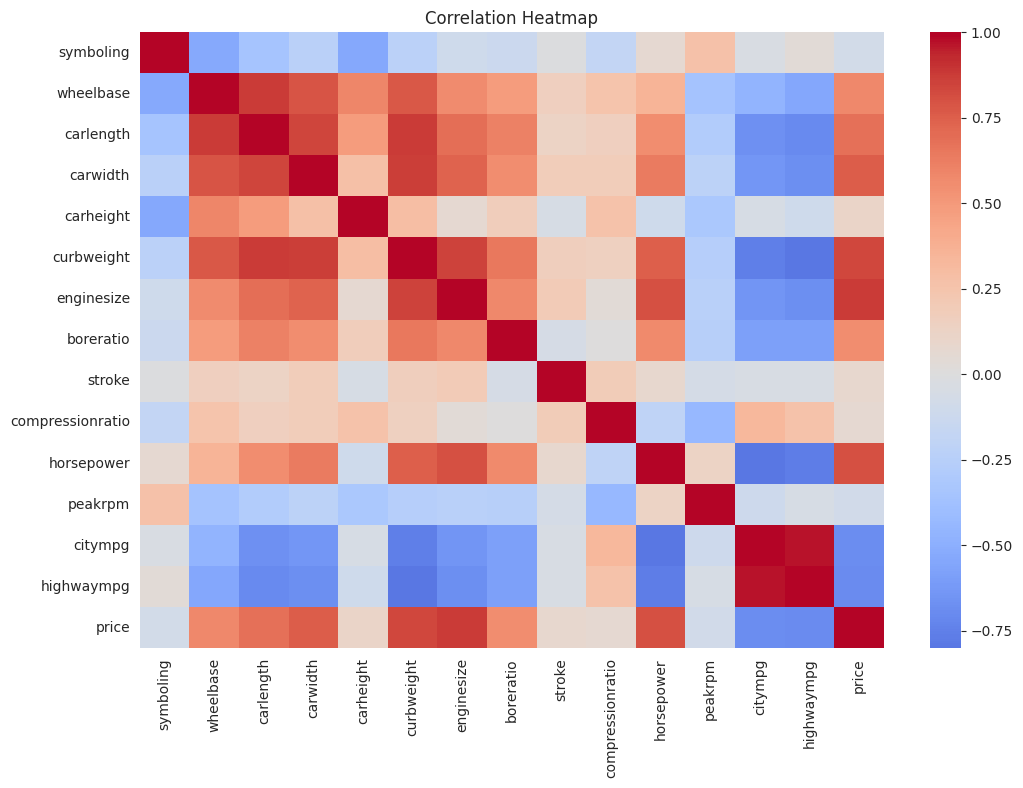

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## 6. Create Input and Target Variables

In [12]:
X = df.drop('price', axis=1)
y = df['price']

print('Input shape:', X.shape)
print('Target shape:', y.shape)

Input shape: (205, 24)
Target shape: (205,)


- `X` contains the features used to predict price.
- `y` contains the target column, `price`.

## 7. Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 164
Testing rows: 41


- 80% of the rows train the models and 20% evaluate them.
- `random_state=42` makes the split reproducible.

## 8. Preprocess Numerical and Categorical Columns

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = X.select_dtypes(include=np.number).columns
categorical_columns = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ]
)

print('Numerical columns:', len(numeric_columns))
print('Categorical columns:', len(categorical_columns))

Numerical columns: 14
Categorical columns: 10


- `StandardScaler()` puts numerical features on a comparable scale. This is important for Ridge and Lasso.
- `OneHotEncoder()` converts text categories into 0/1 columns.
- `handle_unknown='ignore'` prevents errors when the test set contains a new category.
- The preprocessor is fitted only on training data through each pipeline, preventing data leakage.

## 9. Build and Train the Three Models

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=[0.1, 1, 10, 100]))
])

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(alphas=[0.1, 1, 10, 100], cv=5, max_iter=50000))
])

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

print('Best Ridge alpha:', ridge_model.named_steps['model'].alpha_)
print('Best Lasso alpha:', lasso_model.named_steps['model'].alpha_)

Best Ridge alpha: 1.0
Best Lasso alpha: 10.0


- Linear Regression has no coefficient penalty.
- Ridge uses an L2 penalty and shrinks coefficients toward zero.
- Lasso uses an L1 penalty and can make some coefficients exactly zero.
- `RidgeCV` and `LassoCV` use cross-validation on the training data to select an alpha value.

## 10. Predict and Evaluate MAE, MSE, RMSE and R²

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model
}

results = []

for name, model in models.items():
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, test_prediction)
    mse = mean_squared_error(y_test, test_prediction)
    rmse = np.sqrt(mse)
    test_r2 = r2_score(y_test, test_prediction)
    train_r2 = r2_score(y_train, train_prediction)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'R2 Gap': abs(train_r2 - test_r2)
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df.round(3)

,Model,MAE,MSE,RMSE,Train R2,Test R2,R2 Gap
1,Ridge Regression,1881.101,7604006.356,2757.536,0.968,0.904,0.064
0,Linear Regression,1807.704,7808716.036,2794.408,0.975,0.901,0.074
2,Lasso Regression,1936.757,8073740.912,2841.433,0.969,0.898,0.072


- MAE is the average absolute prediction error.
- MSE gives larger errors more weight by squaring them.
- RMSE is in the same unit as price; lower is better.
- R² measures explained variation; higher is better.
- A smaller train-test R² gap usually suggests more stable generalization.

## 11. Compare Model Coefficients

In [17]:
feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()

coefficient_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear': linear_model.named_steps['model'].coef_,
    'Ridge': ridge_model.named_steps['model'].coef_,
    'Lasso': lasso_model.named_steps['model'].coef_
})

coefficient_comparison['Linear_Absolute'] = coefficient_comparison['Linear'].abs()
coefficient_comparison = coefficient_comparison.sort_values(
    'Linear_Absolute', ascending=False
).drop(columns='Linear_Absolute')

coefficient_comparison.head(20).round(2)

,Feature,Linear,Ridge,Lasso
53,cat__CompanyName_bmw,7142.12,4307.46,6482.42
66,cat__CompanyName_porsche,5182.45,3431.90,5245.70
54,cat__CompanyName_buick,4821.62,3559.61,5808.10
28,cat__enginelocation_front,-4624.79,-3441.84,-10117.09
29,cat__enginelocation_rear,4624.79,3441.84,0.00
31,cat__enginetype_dohcv,-4226.34,-1218.03,-0.00
6,num__enginesize,3873.92,3333.69,3213.32
41,cat__cylindernumber_twelve,-3811.97,-1230.15,-0.00
42,cat__cylindernumber_two,3758.70,1669.44,508.56
36,cat__enginetype_rotor,3758.70,1669.44,3866.11


In [19]:
zero_coefficients = (coefficient_comparison['Lasso'].abs() < 1e-8).sum()

print('Total encoded features:', len(coefficient_comparison))
print('Lasso coefficients reduced to zero:', zero_coefficients)

Total encoded features: 73
Lasso coefficients reduced to zero: 28


The coefficient table uses the same encoded and scaled features for all models, so their values can be compared fairly. Ridge usually shrinks coefficients, while Lasso can remove weak features by setting coefficients to zero.

## 12. Visual Comparison of Coefficients

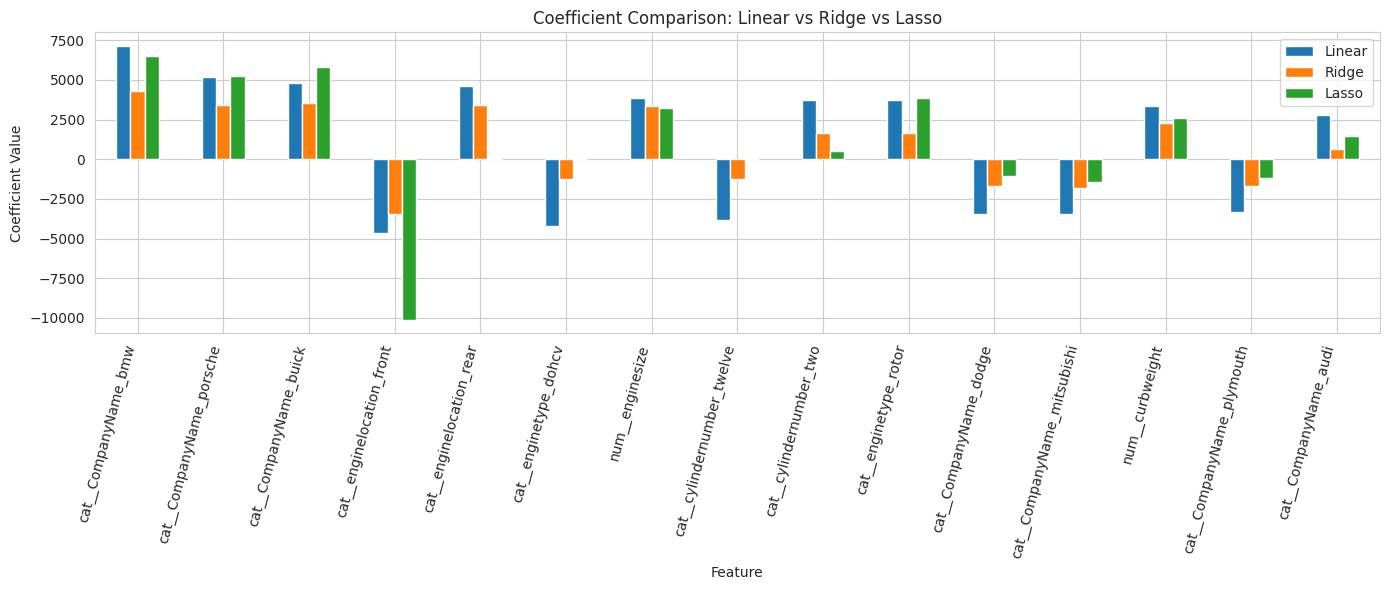

In [20]:
top_coefficients = coefficient_comparison.head(15).set_index('Feature')

top_coefficients.plot(kind='bar', figsize=(14, 6))
plt.title('Coefficient Comparison: Linear vs Ridge vs Lasso')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

## 13. Identify the Model That Generalizes Best

In [21]:
best_model = results_df.iloc[0]

print('Best model based on lowest test RMSE:', best_model['Model'])
print('Test RMSE:', round(best_model['RMSE'], 2))
print('Test R2:', round(best_model['Test R2'], 3))
print('Train-test R2 gap:', round(best_model['R2 Gap'], 3))

Best model based on lowest test RMSE: Ridge Regression
Test RMSE: 2757.54
Test R2: 0.904
Train-test R2 gap: 0.064


## Conclusion

For this train-test split, **Ridge Regression generalizes best**. It has the lowest test RMSE (approximately **2757.54**), the highest test R² (approximately **0.904**), and a smaller train-test R² gap (approximately **0.064**) than the other models. This indicates that Ridge controls coefficient size and reduces overfitting while retaining useful information from all features.

Regularization can improve generalization by controlling large coefficients:

- **Linear Regression:** baseline model without a penalty.
- **Ridge Regression:** reduces coefficient size but normally keeps all features.
- **Lasso Regression:** reduces coefficients and may set weak features to zero.

The exact results are also calculated and printed by the previous cells.